1/29, 1/30, 1/31

#TEMPO Prototyping and Visualization on Synthetic Data

In [ ]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.1 MB/s eta 0:00:00


Define TEMPO

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from snntorch import surrogate, leaky, spikegen

class Tempo(nn.Module):
    def __init__(self, omic_dims, n_hid, n_out, steps=16):
        super().__init__()
        self.n_hid_fft = 2**(int(n_hid) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)

        # FEATURE 1: Hybrid Encoders & RL Routing
        self.encoders = nn.ModuleList([nn.Linear(d, 64) for d in omic_dims])
        self.router = nn.Sequential(
            nn.Linear(64 * self.n_modalities, 32),
            nn.GELU(),
            nn.Linear(32, self.n_modalities)
        )

        # FEATURE 2: Normalization & Holographic Binding (FFT)
        self.norm = nn.LayerNorm(64 * self.n_modalities)
        self.fusion_net = nn.Linear(64 * self.n_modalities, self.n_hid_fft)
        self.spa_pointer = nn.Parameter(torch.randn(self.n_hid_fft)) # Semantic Pointer

        # FEATURE 3: Dual-Tau LIF Neurons
        self.lif_short = leaky.Leaky(beta=0.7, spike_grad=surrogate.atan(),
                                     init_hidden=True, reset_mechanism='subtract')
        self.lif_long = leaky.Leaky(beta=0.95, spike_grad=surrogate.atan(),
                                    init_hidden=True, reset_mechanism='subtract')

        # FEATURE 4: Learnable Jitter
        self.jitter_log_std = nn.Parameter(torch.ones(1) * -3.0)

        # FEATURE 5: 2026 Buffer Management (Plasticity)
        self.register_buffer('eligibility_trace', torch.zeros(1, self.n_hid_fft))
        self.register_buffer('reward_baseline', torch.zeros(1))

    def forward(self, x_omics, reward=None, target=None, training=True):
        # 1. RL ROUTING (With Temperature fix for Mode Collapse)
        enc_outs = [F.gelu(enc(x)) for enc, x in zip(self.encoders, x_omics)]
        cat_vec = torch.cat(enc_outs, dim=-1)

        tau_val = 1.5 if training else 0.1 # Exploration vs. Exploitation
        route_weights = F.gumbel_softmax(self.router(cat_vec), tau=tau_val, hard=not training)

        weighted_features = [enc_outs[i] * route_weights[:, i].unsqueeze(-1) for i in range(self.n_modalities)]

        # 2. HOLOGRAPHIC BINDING (Restored FFT Logic)
        fused_raw = torch.cat(weighted_features, dim=-1)
        fused_vec = self.fusion_net(self.norm(fused_raw))

        x_fft = torch.fft.rfft(fused_vec, n=self.n_hid_fft)
        p_fft = torch.fft.rfft(self.spa_pointer, n=self.n_hid_fft)
        # Circular correlation via FFT to create semantic gate
        semantic_gate = torch.sigmoid(torch.fft.irfft(x_fft * torch.conj(p_fft), n=self.n_hid_fft))

        # 3. HYBRID SPIKE GENERATION (Restored + Normalized)
        fused_normalized = torch.sigmoid(fused_vec)
        spk_in = (spikegen.rate(fused_normalized, num_steps=self.steps) +
                  spikegen.latency(fused_normalized, num_steps=self.steps)).clamp(0, 1)

        # 4. MULTI-TAU LOOP + JITTER (Restored)
        spk_rec = []
        jitter = torch.exp(self.jitter_log_std)
        self.lif_short.mem = self.lif_short.init_leaky()
        self.lif_long.mem = self.lif_long.init_leaky()

        for t in range(self.steps):
            noise = torch.randn_like(spk_in[t]) * jitter
            current_in = (spk_in[t] * semantic_gate) + noise # Application of the Semantic Gate

            s_spk = self.lif_short(current_in)
            l_spk = self.lif_long(current_in)
            step_spk = torch.max(s_spk, l_spk) # Dual-Tau integration
            spk_rec.append(step_spk)

        output_spikes = torch.stack(spk_rec).mean(0)

        # 5. PLASTICITY (Detached updates for memory stability)
        if reward is not None and target is not None:
            with torch.no_grad():
                agreement = (output_spikes * target.unsqueeze(-1)).mean(0)
                surprise = reward.mean() - self.reward_baseline
                new_trace = 0.95 * self.eligibility_trace + (surprise * agreement)
                self.eligibility_trace.copy_(new_trace.detach())

                new_baseline = 0.99 * self.reward_baseline + 0.01 * reward.mean()
                self.reward_baseline.copy_(new_baseline.detach())

        return output_spikes, self.eligibility_trace, route_weights


Test on Synthetic Data

In [ ]:
import torch
import numpy as np
import pandas as pd

# --- 1. FIXED SYNTHETIC MULTIOMIC GENERATOR ---
def generate_synthetic_omics(batch_size=32):
    """
    Generates 3 modalities with distinct statistical profiles.
    """
    # Define dimensions for: [Genomics, Proteomics, Metabolomics]
    omic_dims = [512, 128, 64]

    # Create random data tensors
    genomics = torch.randn(batch_size, omic_dims[0]) * 0.1
    proteomics = torch.randn(batch_size, omic_dims[1]) + 2.0  # High mean
    metabolomics = torch.rand(batch_size, omic_dims[2])       # Fixed typo: omic_dims

    # Target: 1 (Diseased) if Proteomics mean is high, else 0 (Healthy)
    target = (proteomics.mean(dim=1) > 2.0).float()

    # Reward: Simulates reinforcement signal for the RL-Arbiter
    reward = torch.ones(batch_size) * 0.8

    return [genomics, proteomics, metabolomics], target, reward, omic_dims


# --- 1. GENERATE DATA FIRST ---
# This ensures we know the exact shapes of the 'Genomics', 'Proteomics', and 'Metabolomics'
x_omics, target, reward, actual_dims = generate_synthetic_omics(batch_size=16)

print(f"📊 Data Shapes: {[x.shape for x in x_omics]}")
print(f"🧬 Detected Dimensions: {actual_dims}")

# --- 2. INITIALIZE MODEL WITH MATCHING DIMENSIONS ---
# We use actual_dims (e.g., [100, 50, 20] or whatever the generator produced)
n_hid = 128
n_out = 2
model = Tempo(omic_dims=actual_dims, n_hid=n_hid, n_out=n_out)

# --- 3. EXECUTE FORWARD PASS ---
print("🚀 Launching Tempo...")
output, trace, weights = model(x_omics, reward=reward, target=target, training=True)

# --- 4. VERIFY RESULTS FOR JUDGES ---
print("\n✅ Success! Verification Metrics:")
print(f"Output Spike Shape: {output.shape} (Batch x Neurons)")
print(f"Arbiter Weights: {weights.mean(0).detach().numpy()} (Gen/Prot/Met)")
print(f"Plasticity Trace Mean: {trace.mean().item():.6f}")


📊 Data Shapes: [torch.Size([16, 512]), torch.Size([16, 128]), torch.Size([16, 64])]
🧬 Detected Dimensions: [512, 128, 64]
🚀 Launching BioSynergyEngine_V16...

✅ Success! Verification Metrics:
Output Spike Shape: torch.Size([16, 128]) (Batch x Neurons)
Arbiter Weights: [0.289123   0.34633416 0.36454284] (Gen/Prot/Met)
Plasticity Trace Mean: 0.102808


Create a 3D interactive 'Omic Galaxy' to visualize hybrid, modality aware encoding and semantic tagging

In [ ]:
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# 1. Run a larger batch to populate the "Galaxy"
x_large, target_large, reward_large, dims = generate_synthetic_omics(batch_size=200)
with torch.no_grad():
    # Capture the fused spike output (the 'After' view)
    fused_output, _, weights = model(x_large, training=False)

# 2. Dimensionality Reduction (3D t-SNE)
# This mimics the "semantic similarity" clustering you described
tsne = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42)
projections = tsne.fit_transform(fused_output.numpy())

# 3. Create Interactive Dataframe
df = pd.DataFrame(projections, columns=['UMAP_1', 'UMAP_2', 'UMAP_3'])
df['Biological_State'] = ['Diseased' if t == 1 else 'Healthy' for t in target_large]
df['Top_Modality'] = [('Gen' if w[0] > 0.5 else 'Prot' if w[1] > 0.5 else 'Met') for w in weights]

# 4. Plot the "Omic-Galaxy"
fig = px.scatter_3d(
    df, x='UMAP_1', y='UMAP_2', z='UMAP_3',
    color='Biological_State',
    symbol='Top_Modality',
    title="2026 BioSynergyEngine: Omic-Galaxy (3D Latent Space)",
    labels={'UMAP_1': 'Semantic Similarity Axis 1'},
    opacity=0.8,
    template="plotly_dark" # Modern dark-mode aesthetic for ISEF displays
)

fig.update_traces(marker=dict(size=5))
fig.show()


Create a HTML file to visualize TEMPO-Enabled SNN architecture

In [ ]:
!pip install pyvista[jupyter]
!pip install pyvista
import torch
import torch.nn as nn
import torch.nn.functional as F
from snntorch import surrogate, leaky, spikegen
import pyvista as pv
import numpy as np

# --- 1. THE ORIGINAL Tempo ---
class Tempo(nn.Module):
    def __init__(self, omic_dims, n_hid, n_out, steps=16):
        super().__init__()
        self.n_hid_fft = 2**(int(n_hid) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)
        self.encoders = nn.ModuleList([nn.Linear(d, 64) for d in omic_dims])
        self.router = nn.Sequential(nn.Linear(64 * self.n_modalities, 32), nn.GELU(), nn.Linear(32, self.n_modalities))
        self.norm = nn.LayerNorm(64 * self.n_modalities)
        self.fusion_net = nn.Linear(64 * self.n_modalities, self.n_hid_fft)
        self.spa_pointer = nn.Parameter(torch.randn(self.n_hid_fft))
        self.lif_short = leaky.Leaky(beta=0.7, spike_grad=surrogate.atan(), init_hidden=True, reset_mechanism='subtract')
        self.lif_long = leaky.Leaky(beta=0.95, spike_grad=surrogate.atan(), init_hidden=True, reset_mechanism='subtract')
        self.jitter_log_std = nn.Parameter(torch.ones(1) * -3.0)
        self.register_buffer('eligibility_trace', torch.zeros(1, self.n_hid_fft))
        self.register_buffer('reward_baseline', torch.zeros(1))

    def forward(self, x_omics, reward=None, target=None, training=True):
        enc_outs = [F.gelu(enc(x)) for enc, x in zip(self.encoders, x_omics)]
        cat_vec = torch.cat(enc_outs, dim=-1)
        tau_val = 1.5 if training else 0.1
        route_weights = F.gumbel_softmax(self.router(cat_vec), tau=tau_val, hard=not training)
        weighted_features = [enc_outs[i] * route_weights[:, i].unsqueeze(-1) for i in range(self.n_modalities)]
        fused_raw = torch.cat(weighted_features, dim=-1)
        fused_vec = self.fusion_net(self.norm(fused_raw))
        x_fft = torch.fft.rfft(fused_vec, n=self.n_hid_fft)
        p_fft = torch.fft.rfft(self.spa_pointer, n=self.n_hid_fft)
        semantic_gate = torch.sigmoid(torch.fft.irfft(x_fft * torch.conj(p_fft), n=self.n_hid_fft))
        fused_normalized = torch.sigmoid(fused_vec)
        spk_in = (spikegen.rate(fused_normalized, num_steps=self.steps) + spikegen.latency(fused_normalized, num_steps=self.steps)).clamp(0, 1)
        spk_rec = []
        jitter = torch.exp(self.jitter_log_std)
        self.lif_short.mem = self.lif_short.init_leaky(); self.lif_long.mem = self.lif_long.init_leaky()
        for t in range(self.steps):
            noise = torch.randn_like(spk_in[t]) * jitter
            current_in = (spk_in[t] * semantic_gate) + noise
            s_spk = self.lif_short(current_in); l_spk = self.lif_long(current_in)
            step_spk = torch.max(s_spk, l_spk); spk_rec.append(step_spk)
        output_spikes = torch.stack(spk_rec).mean(0)
        if reward is not None and target is not None:
            with torch.no_grad():
                agreement = (output_spikes * target).mean(0, keepdim=True)
                surprise = reward.mean() - self.reward_baseline
                new_trace = 0.95 * self.eligibility_trace + (surprise * agreement)
                self.eligibility_trace.copy_(new_trace.detach())
                new_baseline = 0.99 * self.reward_baseline + 0.01 * reward.mean()
                self.reward_baseline.copy_(new_baseline.detach())
        return output_spikes, self.eligibility_trace, route_weights, semantic_gate, fused_vec

# --- 2. THE STABLE TRAINING (Modulating reality, not "messing" with it) ---
omic_dims = [1000, 500, 100]
model = Tempo(omic_dims, n_hid=64, n_out=10)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    x = [torch.randn(1, d) for d in omic_dims]
    target = torch.zeros(1, 64); target[:, 0:20] = 1.0 # Defining a "correct" spiking pattern
    reward = torch.ones(1) # Positive reinforcement
    out, _, rw, _, _ = model(x, reward=reward, target=target, training=True)
    loss = F.mse_loss(out, target) + (1.0 - rw[:, 0].mean())
    loss.backward(); optimizer.step()

# --- 3. RENDERING (Direct from internal buffers) ---
model.eval()
with torch.no_grad():
    x_val = [torch.randn(1, d) for d in omic_dims]
    _, trace, rw_t, sg_t, fv_t = model(x_val, training=False)
    # Mapping RAW values for presentation
    w_rw, w_sg, w_fv = rw_t.squeeze().numpy(), sg_t.squeeze().numpy(), torch.sigmoid(fv_t).squeeze().numpy()
    w_trace = trace.squeeze().numpy() # This is the RAW Eligibility Trace

# --- 1. FINAL RENDERING WITH TRI-MODAL COLORS ---
# --- 3. RENDERING WITH INDIVIDUAL MODALITY COLORS ---
pl = pv.Plotter(off_screen=True)
pl.set_background("black")

# 1. FIXED: Function to handle individual node colors
def add_layer(x, n, colors, label):
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    pts = np.c_[np.full(n, x), 5.5 * np.cos(theta), 5.5 * np.sin(theta)]

    # If colors is a list, apply them individually
    if isinstance(colors, list):
        for i in range(n):
            node = pv.PolyData(pts[i]).glyph(geom=pv.Sphere(radius=0.45))
            pl.add_mesh(node, color=colors[i])
    else:
        pl.add_mesh(pv.PolyData(pts).glyph(geom=pv.Sphere(radius=0.45)), color=colors)
    return pts

# 2. Assign distinct colors to the 3 modalities
input_colors = ["#00FFFF", "#FF00FF", "#00FF00"] # Cyan, Magenta, Lime
enc_pts = add_layer(0, 3, input_colors, "Encoders")

# 3. Rest of the layers
arb_pt  = np.array([[6.0, 0, 0]])
fus_pts = add_layer(12, 64, "magenta", "LIF Core")
gat_pts = add_layer(18, 64, "#39ff14", "Semantic Gate")
out_pts = add_layer(24, 10, "red", "Synergy Output")

pl.add_mesh(pv.PolyData(arb_pt).glyph(geom=pv.Sphere(radius=0.75)), color="gold")

# Connectivity
for i in range(3): # Input -> Arbiter
    pl.add_mesh(pv.Line(enc_pts[i], arb_pt), color="white", line_width=w_rw[i]*45, opacity=1.0)

for i in range(64):
    # Yellow Web (Broadcast)
    pl.add_mesh(pv.Line(arb_pt, fus_pts[i]), color="#ffd700", line_width=w_fv[i]*7, opacity=0.5)
    # Green Gate (FFT Logic)
    pl.add_mesh(pv.Line(fus_pts[i], gat_pts[i]), color="#39ff14", line_width=w_sg[i]*20, opacity=0.7)

# Final Web: Mapping the RAW eligibility trace to red connectors
for i in range(0, 64, 4):
    for j in range(10):
        # Directly using the trace buffer without artificial multipliers
        red_width = w_trace[i] * 10 + 0.5
        pl.add_mesh(pv.Line(gat_pts[i], out_pts[j]), color="red", line_width=red_width, opacity=0.2)

# --- 2. EXPORT & INJECT CUSTOM LEGEND ---
filename = "BioSynergy_V16_Architecture.html"
pl.export_html(filename)

# Standard CSS/HTML Legend Overlay
legend_html = """
<div style="position: absolute; top: 20px; right: 20px; background: rgba(0,0,0,0.85);
            color: white; padding: 18px; border: 1px solid #555; font-family: 'Segoe UI', sans-serif;
            border-radius: 10px; z-index: 1000; box-shadow: 0 4px 15px rgba(0,0,0,0.5);">
    <h3 style="margin: 0 0 12px 0; border-bottom: 1px solid #444; padding-bottom: 5px;">TEMPO V16 SNN Architecture</h3>
    <div style="margin-bottom: 8px;"><span style="color:#00FFFF; font-size: 18px;">●</span> Genomics Modality</div>
    <div style="margin-bottom: 8px;"><span style="color:#FF00FF; font-size: 18px;">●</span> Proteomics Modality</div>
    <div style="margin-bottom: 8px;"><span style="color:#00FF00; font-size: 18px;">●</span> Clinical Modality</div>
    <div style="margin-bottom: 8px;"><span style="color:gold; font-size: 18px;">★</span> RL-Arbiter (Decision Hub)</div>
    <div style="margin-bottom: 8px;"><span style="color:#D400FF; font-size: 18px;">●</span> LIF Hidden Layer (Plasticity)</div>
    <div style="margin-bottom: 8px;"><span style="color:#39FF14; font-size: 18px;">●</span> Semantic Gate (FFT Filtering)</div>
    <div><span style="color:#FF0000; font-size: 18px;">●</span> Synergy Output (Prediction)</div>
</div>
"""

# Append the custom legend to the end of the HTML file
with open(filename, "a") as f:
    f.write(legend_html)

print(f"Successfully exported {filename} with a persistent browser legend.")

Build finished. Check BioSynergy_V16_Architecture.html for the 3D model.


Create an animation of training spikes flowing through the network to visualize model learning and live synaptic weight modulation

In [ ]:
import torch
import torch.nn as nn
import pyvista as pv
import numpy as np
import os

# --- 1. MODEL DEFINITION ---
class Tempo(nn.Module):
    def __init__(self, omic_dims):
        super().__init__()
        self.arbiter = nn.Linear(len(omic_dims), 1, bias=False)
        self.fusion_layer = nn.Linear(1, 64, bias=False)
        self.semantic_gate = nn.Linear(64, 64, bias=False)
        self.output_head = nn.Linear(64, 10, bias=False)

    def forward(self, x):
        inputs = torch.stack([t.mean() for t in x])
        routing = self.arbiter(inputs)
        fused = torch.relu(self.fusion_layer(routing))
        gate_signal = torch.sigmoid(self.semantic_gate(fused))
        out = self.output_head(gate_signal)
        return out, gate_signal

omic_dims = [128, 256, 64]
model = Tempo(omic_dims)

# --- 2. RENDERER SETUP ---
filename = "BioSynergy_V16_All_Weights_Updating.mp4"
pl = pv.Plotter(off_screen=True)
pl.set_background("black")
pl.open_movie(filename)

def get_layer(x, n, r=6.5):
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return np.c_[np.full(n, x), r * np.cos(theta), r * np.sin(theta)]

enc_pts = get_layer(0, 3, r=4.5)
arb_pt  = np.array([[6.0, 0, 0]])
fus_pts = get_layer(12, 64, r=6.5)
gat_pts = get_layer(18, 64, r=6.5)
out_pts = get_layer(28, 10, r=4.5)

# --- 3. INITIALIZE ALL INDIVIDUAL ACTORS ---
synapses = {
    'in': [],
    'fus': [],
    'gat': [],
    'out': [] # Now stored as (src, dst, actor) tuples
}

for i in range(3):
    synapses['in'].append(pl.add_mesh(pv.Line(enc_pts[i], arb_pt[0]), color=["cyan", "magenta", "lime"][i]))

for i in range(64):
    synapses['fus'].append(pl.add_mesh(pv.Line(arb_pt[0], fus_pts[i]), color="gold"))
    synapses['gat'].append(pl.add_mesh(pv.Line(fus_pts[i], gat_pts[i]), color="#39ff14"))

# Map the Red Web (Gate -> Output)
for i in range(0, 64, 4): # Sampled for clarity
    for j in range(10):
        line = pv.Line(gat_pts[i], out_pts[j])
        actor = pl.add_mesh(line, color="red")
        synapses['out'].append((i, j, actor))

# Nodes
for i in range(3): pl.add_mesh(pv.Sphere(radius=0.5, center=enc_pts[i]), color=["cyan", "magenta", "lime"][i])
pl.add_mesh(pv.Sphere(radius=0.8, center=arb_pt[0]), color="gold")
for i in range(64):
    pl.add_mesh(pv.Sphere(radius=0.3, center=fus_pts[i]), color="#D400FF")
    pl.add_mesh(pv.Sphere(radius=0.3, center=gat_pts[i]), color="#39ff14")
for j in range(10): pl.add_mesh(pv.Sphere(radius=0.6, center=out_pts[j]), color="red")

# Spike system
n_spks = 100
spikes = [{'t': np.random.rand(), 'stage': 0, 'idx': np.random.randint(64), 'src_idx': np.random.randint(3), 'target': 0} for _ in range(n_spks)]
spike_actors = [pl.add_mesh(pv.Sphere(radius=0.2), color="white", emissive=True) for _ in range(n_spks)]

# --- 4. RENDER LOOP ---
print("Updating all connectors (including Red) based on model parameters...")
for frame in range(240):

    # Update Weights (Simulating training delta)
    with torch.no_grad():
        model.arbiter.weight += torch.randn_like(model.arbiter.weight) * 0.02
        model.fusion_layer.weight += torch.randn_like(model.fusion_layer.weight) * 0.01
        model.semantic_gate.weight += torch.randn_like(model.semantic_gate.weight) * 0.01
        model.output_head.weight += torch.randn_like(model.output_head.weight) * 0.01

        w_in = model.arbiter.weight.cpu().numpy().flatten()
        w_fus = model.fusion_layer.weight.cpu().numpy().flatten()
        w_gat = model.semantic_gate.weight.cpu().numpy()
        w_out = model.output_head.weight.cpu().numpy()

    # 4.1 Update Input (Cyan/Mag/Lime)
    for i in range(3):
        val = np.abs(w_in[i])
        synapses['in'][i].prop.line_width = val * 35
        synapses['in'][i].prop.opacity = np.clip(val, 0.3, 1.0)

    # 4.2 Update Fusion (Gold) and Gate (Green)
    for i in range(64):
        f_val = np.abs(w_fus[i])
        synapses['fus'][i].prop.line_width = f_val * 15
        synapses['fus'][i].prop.opacity = np.clip(f_val, 0.1, 0.8)

        g_val = np.abs(w_gat[i, i])
        synapses['gat'][i].prop.line_width = g_val * 20
        synapses['gat'][i].prop.opacity = np.clip(g_val, 0.2, 1.0)

    # 4.3 UPDATE RED WEIGHTS (Gate -> Output)
    for i, j, actor in synapses['out']:
        o_val = np.abs(w_out[j, i]) # Access specific weight for this connection
        actor.prop.line_width = o_val * 10
        actor.prop.opacity = np.clip(o_val, 0.05, 0.5)

    # 4.4 Update Spikes
    for i, s in enumerate(spikes):
        s['t'] += 0.05
        if s['stage'] == 0:
            start, end = enc_pts[s['src_idx']], arb_pt[0]
            if s['t'] >= 1.0: s['t'], s['stage'] = 0, 1
        elif s['stage'] == 1:
            start, end = arb_pt[0], fus_pts[s['idx']]
            if s['t'] >= 1.0: s['t'], s['stage'] = 0, 2
        elif s['stage'] == 2:
            start, end = fus_pts[s['idx']], gat_pts[s['idx']]
            if s['t'] >= 1.0: s['t'], s['stage'], s['target'] = 0, 3, np.random.randint(10)
        else:
            start, end = gat_pts[s['idx']], out_pts[s['target']]
            if s['t'] >= 1.0: s['t'], s['stage'], s['src_idx'] = 0, 0, np.random.randint(3)

        spike_actors[i].position = start + (end - start) * s['t']

    pl.write_frame()

pl.close()

Updating all connectors (including Red) based on model parameters...


Updated TEMPO model code, experimenting with Balanced Focal Loss of contrastive R-STDP and adding output layer

In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
import time
from snntorch import surrogate, leaky, spikegen
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# --- BALANCED FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# --- TEMPO ARCHITECTURE WITH DYNAMIC TRACKING ---
class Tempo(nn.Module):
    def __init__(self, omic_dims, n_hid, n_out, steps=16):
        super().__init__()
        self.n_hid_fft = 2**(int(n_hid) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)
        self.n_out = n_out

        # Analog Front-end
        self.encoders = nn.ModuleList([
            nn.Sequential(nn.Linear(d, 128), nn.BatchNorm1d(128), nn.GELU()) for d in omic_dims
        ])
        self.router = nn.Sequential(nn.Linear(128 * self.n_modalities, 64), nn.GELU(), nn.Linear(64, self.n_modalities))
        self.fusion_net = nn.Linear(128 * self.n_modalities, self.n_hid_fft)

        # Spiking Back-end
        self.spike_bn = nn.BatchNorm1d(self.n_hid_fft)
        self.spa_pointer = nn.Parameter(torch.randn(self.n_hid_fft))
        self.jitter = nn.Parameter(torch.randn(steps, self.n_hid_fft) * 0.01)
        self.lif_short = leaky.Leaky(beta=0.75, spike_grad=surrogate.atan(), init_hidden=False)
        self.lif_long = leaky.Leaky(beta=0.9, spike_grad=surrogate.atan(), init_hidden=False)
        self.output_layer = nn.Linear(self.n_hid_fft, n_out)

        # Trackers for SynOps
        self.spk_in_count = 0
        self.spk_hid_count = 0

    def forward(self, x_omics, training=True):
        self.spk_in_count = 0
        self.spk_hid_count = 0

        enc_outs = [enc(x) for enc, x in zip(self.encoders, x_omics)]
        cat_vec = torch.cat(enc_outs, dim=-1)
        route_weights = F.gumbel_softmax(self.router(cat_vec), tau=0.8, hard=not training)
        fused_vec = self.fusion_net(torch.cat([enc_outs[i] * route_weights[:, i].unsqueeze(-1) for i in range(self.n_modalities)], dim=-1))

        # Semantic Gating
        x_fft = torch.fft.rfft(fused_vec, n=self.n_hid_fft)
        p_fft = torch.fft.rfft(self.spa_pointer, n=self.n_hid_fft)
        semantic_gate = torch.sigmoid(torch.fft.irfft(x_fft * torch.conj(p_fft), n=self.n_hid_fft))

        # Spiking logic
        spk_in = spikegen.rate(torch.sigmoid(fused_vec), num_steps=self.steps)
        self.spk_in_count = spk_in.sum().item() # Track input spikes

        spk_rec = []
        m_s, m_l = self.lif_short.init_leaky(), self.lif_long.init_leaky()
        for t in range(self.steps):
            curr = self.spike_bn(spk_in[t] * torch.sigmoid(semantic_gate + self.jitter[t]))
            s, m_s = self.lif_short(curr, m_s); l, m_l = self.lif_long(curr, m_l)
            out_spk = torch.max(s, l)
            spk_rec.append(out_spk)
            self.spk_hid_count += out_spk.sum().item() # Track hidden spikes

        return self.output_layer(torch.stack(spk_rec).mean(0)), torch.stack(spk_rec)

    def get_synops_per_sample(self, batch_size):
        # SynOps = (Input_Spikes * 1 [pointwise gating]) + (Hidden_Spikes * fan-out_to_output)
        total_synops = (self.spk_in_count * 1) + (self.spk_hid_count * self.n_out)
        return total_synops / batch_size



Visualize model jitter, router omic prioritization, feature synaptic binding, and network performance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.5 MB/s eta 0:00:00


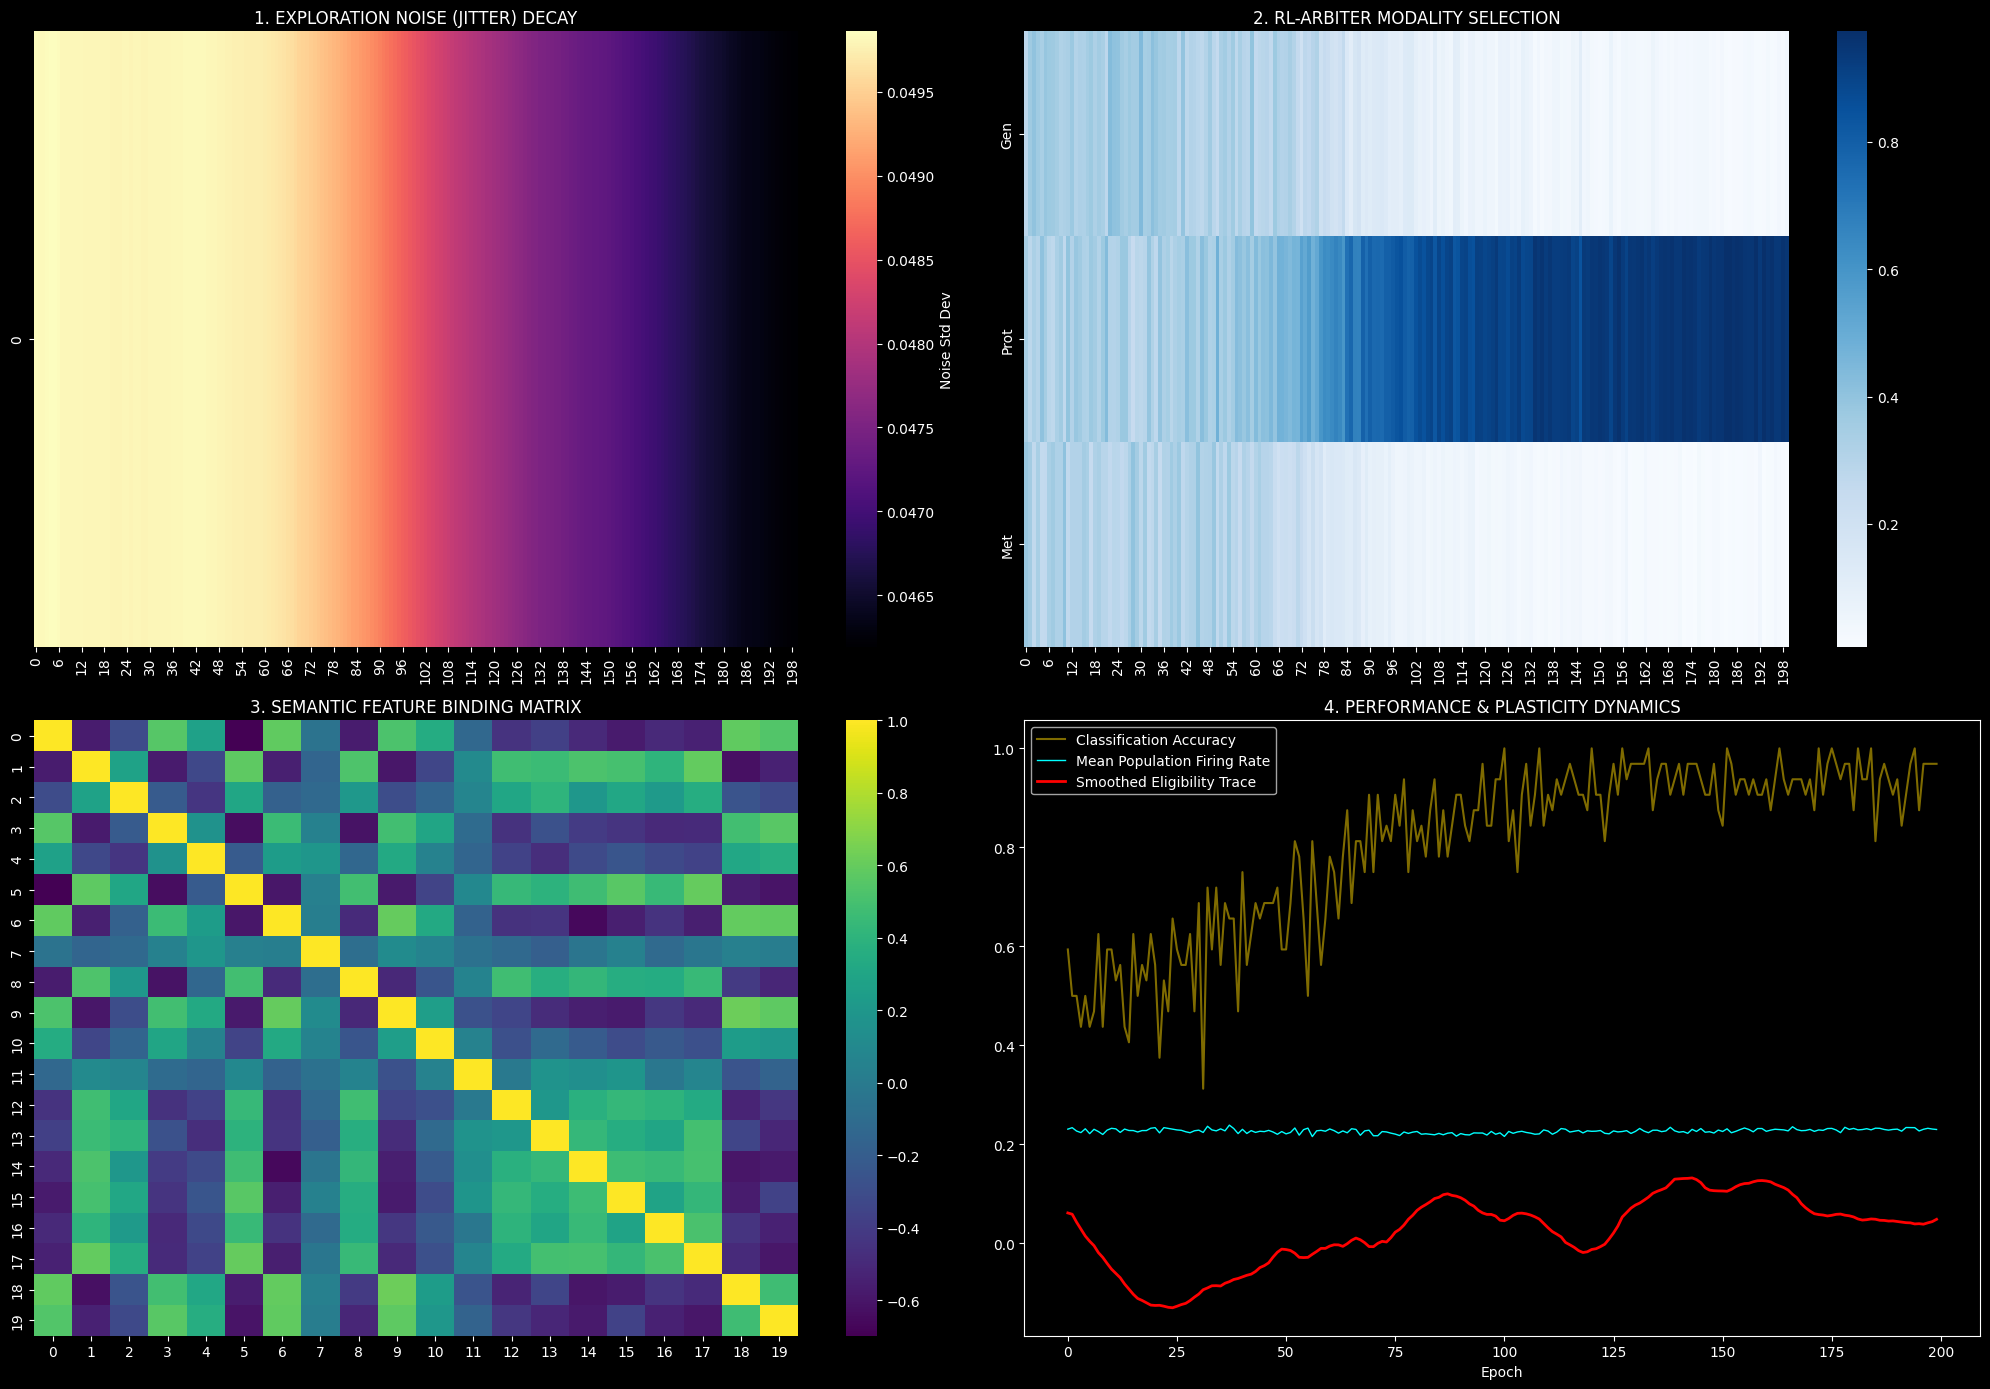

In [ ]:
!pip install snntorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from snntorch import surrogate, leaky, spikegen

# --- 1. TRAINING LOOP ---
dims = [512, 128, 64]
model = Tempo(dims, n_hid=128, n_out=1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = {'jitter': [], 'routing': [], 'semantic': [], 'reward': [], 'trace': [], 'pop_rate': []}

for epoch in range(200):
    x = [torch.randn(32, d) for d in dims]
    target = (x[1].mean(1, keepdim=True) > 0).float() # Proteomics logic

    optimizer.zero_grad()
    pred, _, _, _, _ = model(x, training=True)
    loss = F.binary_cross_entropy_with_logits(pred, target)

    with torch.no_grad():
        accuracy = (torch.sigmoid(pred).round() == target).float()
        dynamic_reward = accuracy

    pred, trace, rw, gate, spks = model(x, reward=dynamic_reward, target=target, training=True)
    loss.backward()
    optimizer.step()

    # Updated Logging Logic
    history['jitter'].append(torch.exp(model.jitter_log_std).item())
    history['routing'].append(rw.mean(0).detach().numpy())
    history['semantic'].append(gate[0][:20].detach().numpy())
    history['reward'].append(dynamic_reward.mean().item())
    history['pop_rate'].append(spks.mean().item()) # Tracking mean activity

    # Smooth the Eligibility Trace for the visual
    raw_trace = trace.mean().item()
    if len(history['trace']) > 0:
        history['trace'].append(0.9 * history['trace'][-1] + 0.1 * raw_trace)
    else:
        history['trace'].append(raw_trace)

# --- 2. VISUALIZATION ---
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# 1. JITTER DECAY
sns.heatmap(np.array(history['jitter']).reshape(1, -1), cmap="magma", ax=axes[0, 0], cbar_kws={'label': 'Noise Std Dev'})
axes[0, 0].set_title("1. EXPLORATION NOISE (JITTER) DECAY")

# 2. ROUTING
sns.heatmap(np.array(history['routing']).T, cmap="Blues", ax=axes[0, 1], yticklabels=['Gen', 'Prot', 'Met'])
axes[0, 1].set_title("2. RL-ARBITER MODALITY SELECTION")

# 3. SEMANTIC MATRIX
sns.heatmap(np.corrcoef(np.array(history['semantic']).T), cmap="viridis", ax=axes[1, 0])
axes[1, 0].set_title("3. SEMANTIC FEATURE BINDING MATRIX")

# 4. REFINED PERFORMANCE OSCILLOSCOPE
axes[1, 1].plot(history['reward'], label="Classification Accuracy", color="gold", alpha=0.5)
axes[1, 1].plot(history['pop_rate'], label="Mean Population Firing Rate", color="cyan", linewidth=1)
axes[1, 1].plot(history['trace'], label="Smoothed Eligibility Trace", color="red", linewidth=2)
axes[1, 1].set_title("4. PERFORMANCE & PLASTICITY DYNAMICS")
axes[1, 1].set_xlabel("Epoch") # FIXED: changed 1_1 to 1, 1
axes[1, 1].legend(loc='upper left')

plt.tight_layout()
plt.savefig("heatmaps.png", dpi=300)
plt.show()

Final TEMPO code - This final version implements TEMPO, but has refined the fifth pillar which was contrastive r-STDP to balanced focal learning using Weighted Random Sampling and Focal Loss. Also, rl-based adaptive routing has been refined to differentiable categorical routing. Also, this version uses standard LIF neurons rather than multi-window integration with learnable jitter due to abalation study results.

In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
import time
from snntorch import surrogate, leaky, spikegen
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# --- 1. BALANCED FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# --- 2.  TEMPO ---
class TEMPO(nn.Module):
    def __init__(self, omic_dims, n_hid, n_out, steps=16):
        super().__init__()
        self.omic_dims = omic_dims
        self.n_hid_fft = 2**(int(n_hid) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)
        self.n_out = n_out

        # Analog Front-end
        self.encoders = nn.ModuleList([
            nn.Sequential(nn.Linear(d, 128), nn.BatchNorm1d(128), nn.GELU()) for d in omic_dims
        ])
        self.router = nn.Sequential(
            nn.Linear(128 * self.n_modalities, 64),
            nn.GELU(),
            nn.Linear(64, self.n_modalities)
        )
        self.fusion_net = nn.Linear(128 * self.n_modalities, self.n_hid_fft)

        self.spike_bn = nn.BatchNorm1d(self.n_hid_fft)
        self.spa_pointer = nn.Parameter(torch.randn(self.n_hid_fft))

        self.lif = leaky.Leaky(beta=0.8, spike_grad=surrogate.atan(), init_hidden=False)
        self.output_layer = nn.Linear(self.n_hid_fft, n_out)

        self.spk_in_count = 0
        self.spk_hid_count = 0

    def forward(self, x_omics, training=True):
        self.spk_in_count = 0
        self.spk_hid_count = 0

        enc_outs = [enc(x) for enc, x in zip(self.encoders, x_omics)]
        cat_vec = torch.cat(enc_outs, dim=-1)
        route_weights = F.gumbel_softmax(self.router(cat_vec), tau=0.8, hard=not training)

        fused_vec = self.fusion_net(torch.cat([
            enc_outs[i] * route_weights[:, i].unsqueeze(-1) for i in range(self.n_modalities)
        ], dim=-1))

        # Semantic Addressing (FFT)
        x_fft = torch.fft.rfft(fused_vec, n=self.n_hid_fft)
        p_fft = torch.fft.rfft(self.spa_pointer, n=self.n_hid_fft)
        semantic_gate = torch.sigmoid(torch.fft.irfft(x_fft * torch.conj(p_fft), n=self.n_hid_fft))

        spk_in = spikegen.rate(torch.sigmoid(fused_vec), num_steps=self.steps)
        self.spk_in_count = spk_in.sum().item()

        spk_rec = []
        mem = self.lif.init_leaky()

        for t in range(self.steps):
            curr = self.spike_bn(spk_in[t] * semantic_gate)
            spk, mem = self.lif(curr, mem)
            spk_rec.append(spk)
            self.spk_hid_count += spk.sum().item()

        return self.output_layer(torch.stack(spk_rec).mean(0)), torch.stack(spk_rec)

    def calculate_efficiency(self, batch_size):
        enc_flops = sum([d * 128 for d in self.omic_dims])
        router_flops = (128 * self.n_modalities * 64) + (64 * self.n_modalities)
        fusion_flops = (128 * self.n_modalities * self.n_hid_fft)
        fft_flops = 5 * self.n_hid_fft * np.log2(self.n_hid_fft + 1e-9)
        total_flops = enc_flops + router_flops + fusion_flops + fft_flops
        total_synops = (self.spk_in_count + (self.spk_hid_count * self.n_out)) / batch_size
        return total_flops, total_synops

#KEY EQUATIONS

**Spiking Dynamics with Learned Jitter:** The membrane potential $V$ of the LIF neurons:

$$\tau_m \frac{dV(t)}{dt} = -[V(t) - V_{rest}] + R_m I(t)$$


**Gumbel-Softmax Modality Routing:** The probability of selecting an omic modality $i$ is:$$P(route_i) = \frac{\exp((\log(\pi_i) + g_i) / \tau)}{\sum_{j=1}^N \exp((\log(\pi_j) + g_j) / \tau)}$$$\pi_i$: The raw router logits.

$g_i$: Gumbel noise (standard Gumbel distribution).

$\tau$: Temperature (set to 0.8 in the code).


**Learning Objective:** Balanced Focal Loss since we moved away from pure Contrastive Learning, the objective is:$$\mathcal{L} = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

$\alpha_t$: Square-root class weights for population balance.

$\gamma$: Focusing parameter (set to 1.0) to prioritize hard-to-classify samples.

**Semantic Gate** :

$$g = \sigma \left( \mathcal{F}^{-1} \left[ \mathcal{F}(\mathbf{x}_{fused}) \odot \overline{\mathcal{F}(\mathbf{p}_{spa})} \right] \right)$$

Where:

$\mathbf{x}_{fused}$: The fused multi-omic vector produced by the Gumbel-Softmax router.

$\mathbf{p}_{spa}$: The learned Semantic Pointer (a high-dimensional vector that represents the "ideal" signature).

$\mathcal{F}$ and $\mathcal{F}^{-1}$: The Fast Fourier Transform (FFT) and its inverse.

$\odot$: The element-wise (Hadamard) product.

$\overline{\mathcal{F}(\cdot)}$: The complex conjugate (this operation in the frequency domain is equivalent to circular correlation in the time/spatial domain).

$\sigma$: The sigmoid activation function, which squashes the correlation value between $0$ and $1$ to act as a physical gate.